In [17]:
!pip install pandas numpy torch scikit-learn matplotlib
!pip install xgboost
!pip install lightgbm

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)


Kullanılan cihaz: cuda


In [19]:
df = pd.read_csv("/content/drive/MyDrive/diabetic_data_processed.csv")

X = df.drop("target", axis=1)
y = df["target"]

print("Veri seti başarıyla yüklendi.")

Veri seti başarıyla yüklendi.


In [20]:
print("VERİ SETİ GENEL BİLGİLERİ")
print(f"Toplam örnek sayısı: {X.shape[0]}")
print(f"Toplam özellik sayısı: {X.shape[1]}")
print(f"Sınıf sayısı: {y.nunique()}")


VERİ SETİ GENEL BİLGİLERİ
Toplam örnek sayısı: 101763
Toplam özellik sayısı: 132
Sınıf sayısı: 2


SINIF DAĞILIMI
target
0    90406
1    11357
Name: count, dtype: int64


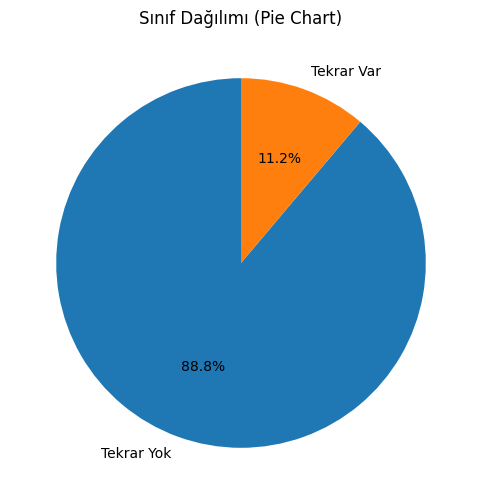

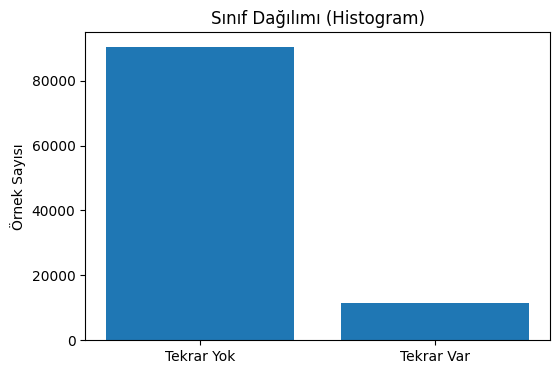

In [21]:
sinif_sayilari = y.value_counts()

print("SINIF DAĞILIMI")
print(sinif_sayilari)

plt.figure(figsize=(6,6))
plt.pie(
    sinif_sayilari,
    labels=["Tekrar Yok", "Tekrar Var"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sınıf Dağılımı (Pie Chart)")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["Tekrar Yok", "Tekrar Var"], sinif_sayilari)
plt.title("Sınıf Dağılımı (Histogram)")
plt.ylabel("Örnek Sayısı")
plt.show()


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test bölünmesi sınıf dağılımı korunarak yapılmıştır.")

Train-test bölünmesi sınıf dağılımı korunarak yapılmıştır.


In [23]:
print("XGBoost modeli tanımlanıyor...")


xgb_model = XGBClassifier(
    n_estimators=300,        # Modelin oluşturacağı toplam karar ağacı (tur) sayısı
    max_depth=6,             # Her bir karar ağacının maksimum derinliği (karmaşıklığı kontrol eder)
    learning_rate=0.05,      # Öğrenme oranı; her ağacın sonuca katkısını belirler (düşük değerler genelleştirmeyi artırır)
    subsample=0.8,           # Her ağaç eğitilirken eğitim verisinin rastgele seçilecek oranı (overfitting'i engeller)
    colsample_bytree=0.8,    # Her ağaç oluşturulurken kullanılacak sütunların (özniteliklerin) oranı
    # Sınıf dengesizliğini yönetmek için negatif/pozitif sınıf ağırlıklandırması:
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    objective="binary:logistic", # İkili sınıflandırma için olasılık tabanlı lojistik regresyon hedefi
    eval_metric="auc",       # Eğitim sırasında takip edilecek performans metriği (ROC-AUC)
    random_state=42,         # Sonuçların tekrarlanabilir (tutarlı) olması için rastgelelik sabitlenir
    n_jobs=-1                # Mevcut tüm işlemci çekirdeklerini kullanarak eğitimi hızlandırır
)

print("XGBoost modeli hazır.")


XGBoost modeli tanımlanıyor...
XGBoost modeli hazır.


In [24]:
print("LightGBM modeli tanımlanıyor...")

lgbm_model = LGBMClassifier(
    n_estimators=400,        # Oluşturulacak toplam karar ağacı (iterasyon) sayısı
    learning_rate=0.05,      # Öğrenme oranı; her ağacın hatayı düzeltme katsayısı (düşük değerler daha hassas öğrenme sağlar)
    num_leaves=31,           # Bir ağaçtaki maksimum yaprak sayısı; model karmaşıklığını ve doğruluğunu etkiler
    subsample=0.8,           # Her ağaç eğitilirken eğitim verisinin rastgele seçilecek oranı (overfitting'i azaltır)
    colsample_bytree=0.8,    # Her ağaç oluşturulurken kullanılacak özniteliklerin (sütunların) oranı
    class_weight="balanced", # Veri setindeki sınıf dengesizliğini otomatik olarak ağırlıklandırarak dengeler (Diyabet vakaları azsa kritiktir)
    random_state=42,         # Sonuçların her çalışmada aynı çıkması için kullanılan rastgelelik tohumu
    n_jobs=-1                # Bilgisayardaki tüm işlemci çekirdeklerini kullanarak eğitimi hızlandırır
)

print("LightGBM modeli hazır.")


LightGBM modeli tanımlanıyor...
LightGBM modeli hazır.


In [25]:
print("XGBoost eğitiliyor...")
xgb_model.fit(X_train, y_train)
print("XGBoost eğitimi tamamlandı.")

print("\nLightGBM eğitiliyor...")
lgbm_model.fit(X_train, y_train)
print("LightGBM eğitimi tamamlandı.")


XGBoost eğitiliyor...
XGBoost eğitimi tamamlandı.

LightGBM eğitiliyor...
[LightGBM] [Info] Number of positive: 9086, number of negative: 72324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.252140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 494
[LightGBM] [Info] Number of data points in the train set: 81410, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM eğitimi tamamlandı.


In [26]:
def evaluate_model(model, model_adi):
    """
    Verilen modeli test verileri üzerinde değerlendirir, temel metrikleri yazdırır
    ve hata matrisi ile ROC eğrisini görselleştirir.
    """
    print(f"\n{model_adi} TEST SONUÇLARI")
    print("--------------------------------")

    # Sınıf 1 (Pozitif sınıf) için tahmin olasılıklarını alıyoruz
    y_prob = model.predict_proba(X_test)[:, 1]

    # Olasılık değerlerini 0.5 eşik değerine göre 0 veya 1 etiketlerine dönüştürüyoruz
    y_pred = (y_prob > 0.5).astype(int)

    # Temel performans metriklerinin hesaplanması ve ekrana yazdırılması
    print("Doğruluk (Accuracy):", round(accuracy_score(y_test, y_pred), 4)) # Genel doğru tahmin oranı
    print("Kesinlik (Precision):", round(precision_score(y_test, y_pred), 4)) # Pozitif tahminlerin ne kadarının doğru olduğu
    print("Duyarlılık (Recall):", round(recall_score(y_test, y_pred), 4))    # Gerçek pozitiflerin ne kadarının yakalandığı
    print("F1 Skoru:", round(f1_score(y_test, y_pred), 4))                # Kesinlik ve Duyarlılığın harmonik ortalaması
    print("ROC-AUC Skoru:", round(roc_auc_score(y_test, y_prob), 4))       # Modelin sınıfları birbirinden ayırma gücü

    # Karışıklık Matrisi (Confusion Matrix) hesaplanması ve görselleştirilmesi
    # Bu matris, modelin hangi sınıfları birbiriyle karıştırdığını gösterir.
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        cm, display_labels=["Tekrar Yok", "Tekrar Var"]
    ).plot(cmap="Blues")
    plt.title(f"{model_adi} – Karışıklık Matrisi")
    plt.show()



    # ROC Eğrisi (Receiver Operating Characteristic) oluşturma
    # Modelin farklı eşik değerlerindeki performansını görselleştirmek için kullanılır.
    fpr, tpr, _ = roc_curve(y_test, y_prob) # Yanlış Pozitif Oranı ve Doğru Pozitif Oranı hesaplanır
    plt.plot(fpr, tpr, label=model_adi)
    plt.plot([0,1],[0,1],'--') # Şans seviyesini (rastgele tahmin) temsil eden referans çizgisi
    plt.xlabel("Yanlış Pozitif Oranı")
    plt.ylabel("Doğru Pozitif Oranı")
    plt.title(f"{model_adi} – ROC Eğrisi")
    plt.legend()
    plt.show()



    # Karşılaştırma analizlerinde kullanmak üzere sonuçları bir sözlük (dictionary) olarak döndürüyoruz
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


XGBoost TEST SONUÇLARI
--------------------------------
Doğruluk (Accuracy): 0.6866
Kesinlik (Precision): 0.192
Duyarlılık (Recall): 0.5636
F1 Skoru: 0.2864
ROC-AUC Skoru: 0.6871


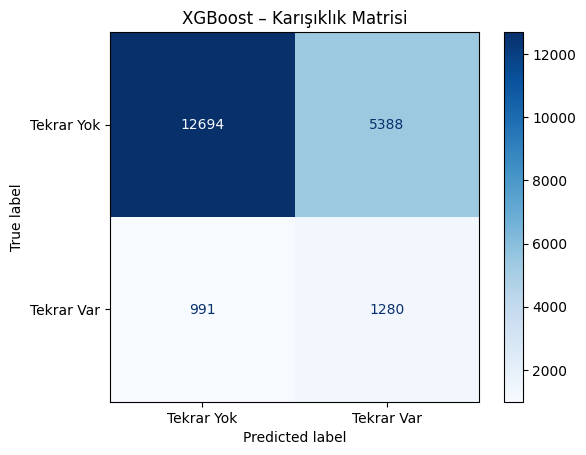

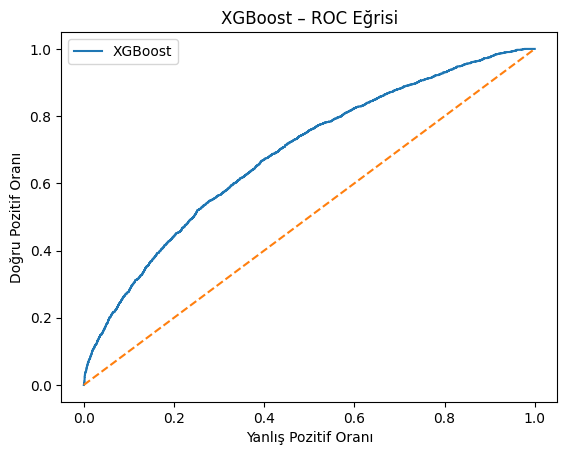


LightGBM TEST SONUÇLARI
--------------------------------
Doğruluk (Accuracy): 0.6861
Kesinlik (Precision): 0.1923
Duyarlılık (Recall): 0.5663
F1 Skoru: 0.2871
ROC-AUC Skoru: 0.6875


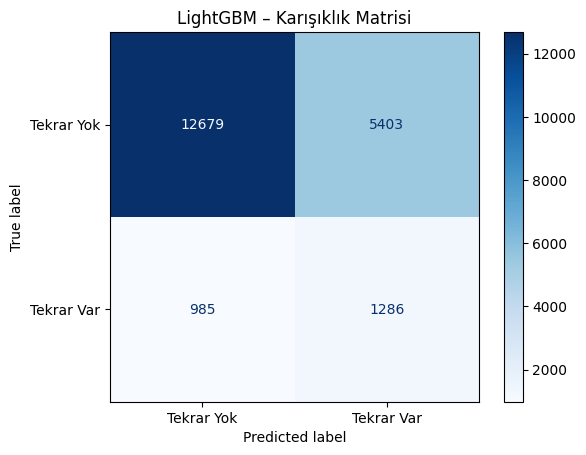

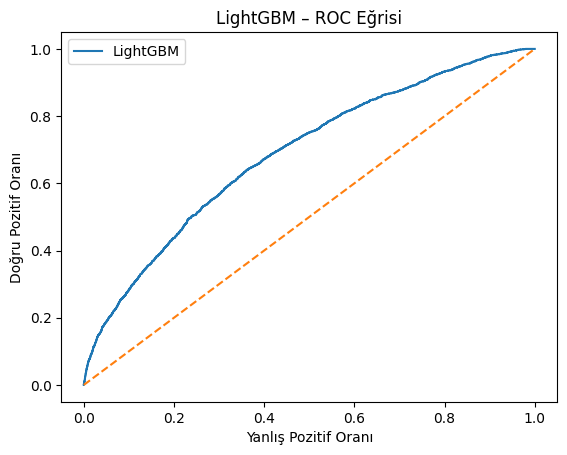

In [27]:
sonuc_xgb = evaluate_model(xgb_model, "XGBoost")
sonuc_lgbm = evaluate_model(lgbm_model, "LightGBM")


In [28]:
print("\nXGBoost SINIF BAZLI PERFORMANS")
print(classification_report(
    y_test, xgb_model.predict(X_test),
    target_names=["Tekrar Yok", "Tekrar Var"]
))

print("\nLightGBM SINIF BAZLI PERFORMANS")
print(classification_report(
    y_test, lgbm_model.predict(X_test),
    target_names=["Tekrar Yok", "Tekrar Var"]
))



XGBoost SINIF BAZLI PERFORMANS
              precision    recall  f1-score   support

  Tekrar Yok       0.93      0.70      0.80     18082
  Tekrar Var       0.19      0.56      0.29      2271

    accuracy                           0.69     20353
   macro avg       0.56      0.63      0.54     20353
weighted avg       0.85      0.69      0.74     20353


LightGBM SINIF BAZLI PERFORMANS
              precision    recall  f1-score   support

  Tekrar Yok       0.93      0.70      0.80     18082
  Tekrar Var       0.19      0.57      0.29      2271

    accuracy                           0.69     20353
   macro avg       0.56      0.63      0.54     20353
weighted avg       0.85      0.69      0.74     20353



In [29]:
tum_sonuclar = pd.DataFrame(
    [sonuc_xgb, sonuc_lgbm],
    index=["XGBoost", "LightGBM"]
)

print("GENEL MODEL KARŞILAŞTIRMA TABLOSU")
tum_sonuclar


GENEL MODEL KARŞILAŞTIRMA TABLOSU


,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost,0.686582,0.191962,0.563628,0.286386,0.687098
LightGBM,0.686140,0.192256,0.566270,0.287054,0.687482


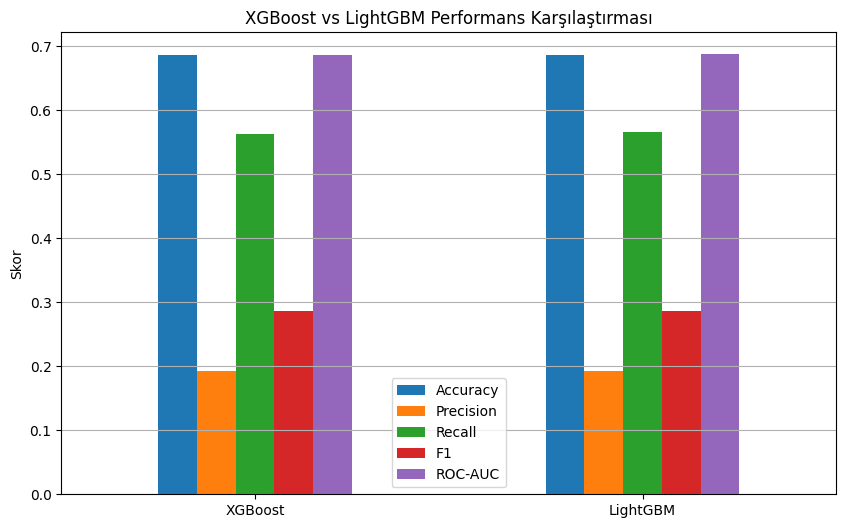

In [30]:
tum_sonuclar.plot(kind="bar", figsize=(10,6))
plt.title("XGBoost vs LightGBM Performans Karşılaştırması")
plt.ylabel("Skor")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


In [31]:
import joblib

# En iyi model olan LightGBM modelini (lgbm_model) kaydediyoruz
model_dosya_adi = 'en_iyi_diyabet_modeli.pkl'
joblib.dump(lgbm_model, model_dosya_adi)

print(f"Model başarıyla '{model_dosya_adi}' adıyla kaydedildi.")

Model başarıyla 'en_iyi_diyabet_modeli.pkl' adıyla kaydedildi.


In [32]:
import joblib

# Kaydedilen modeli yükleme
yuklenen_model = joblib.load('en_iyi_diyabet_modeli.pkl')

# Örnek kullanım (X_test verisi ile tahmin yapma)
# tahminler = yuklenen_model.predict(X_test)
print("Model yüklendi ve kullanıma hazır.")

Model yüklendi ve kullanıma hazır.
